In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import drive
drive.mount('/content/drive')
# After mounting, you can access your files in '/content/drive/My Drive/'
# Replace 'path/to/your_dataset_in_drive/yellow_tripdata_2024_combined.csv' with the actual path to your file
df = pd.read_excel('/content/drive/My Drive/ai_projects/car_price_hackthon_sha/data/car_price.xlsx', sheet_name='VehicleSales')

if df.empty:
    print("Warning: The DataFrame loaded from 'car_price.xlsx' is empty. Please check the Excel file content or specify a sheet_name if needed.")
else:
    print("DataFrame loaded successfully!")

Mounted at /content/drive
DataFrame loaded successfully!


In [4]:
df

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00
558834,558836,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00
558835,558837,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00


# Explore Data

In [5]:
df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [6]:
df.shape

(558837, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              558837 non-null  int64  
 1   Year            558837 non-null  int64  
 2   Make            548536 non-null  object 
 3   Model           548438 non-null  object 
 4   Trim            548186 non-null  object 
 5   Body            545642 non-null  object 
 6   Transmission    493485 non-null  object 
 7   VIN             558833 non-null  object 
 8   State           558837 non-null  object 
 9   ConditionValue  547017 non-null  float64
 10  Odometer        558743 non-null  float64
 11  Color           558088 non-null  object 
 12  Interior        558088 non-null  object 
 13  Seller          558837 non-null  object 
 14  MMR             558799 non-null  float64
 15  SellingPrice    558825 non-null  float64
 16  SaleDate        558799 non-null  object 
dtypes: float64

In [8]:
df.isnull().sum()

,0
Id,0
Year,0
Make,10301
Model,10399
Trim,10651
Body,13195
Transmission,65352
VIN,4
State,0
ConditionValue,11820


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df:
    print(f"\n{col} value counts:\n", df[col].value_counts())


Id value counts:
 Id
558838    1
2         1
3         1
4         1
5         1
         ..
11        1
10        1
9         1
8         1
7         1
Name: count, Length: 558837, dtype: int64

Year value counts:
 Year
2012    102315
2013     98168
2014     81070
2011     48548
2008     31502
2007     30845
2006     26913
2010     26485
2005     21394
2009     20594
2004     17342
2003     13281
2002      9715
2015      9437
2001      6468
2000      5227
1999      3363
1998      2149
1997      1546
1996       851
1995       711
1994       392
1993       205
1992       132
1991        67
1990        49
1989        20
1986        11
1988        11
1985        10
1987         8
1984         5
1982         2
1983         1
Name: count, dtype: int64

Make value counts:
 Make
Ford          93554
Chevrolet     60197
Nissan        53946
Toyota        39871
Dodge         30710
              ...  
ford tk           1
chev truck        1
airstream         1
dot               1
Lotus           

# Cleaning

In [11]:
# Drop columns with no analytical value
df.drop(columns=['VIN', 'Id'], inplace=True)

In [12]:
df.head()

,Year,Make,Model,Trim,Body,Transmission,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,2015,Volvo,S60,T5,Sedan,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [13]:
# Convert SaleDate from object to datetime
df['SaleDate'] = pd.to_datetime(df['SaleDate'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Year            558837 non-null  int64         
 1   Make            548536 non-null  object        
 2   Model           548438 non-null  object        
 3   Trim            548186 non-null  object        
 4   Body            545642 non-null  object        
 5   Transmission    493485 non-null  object        
 6   State           558837 non-null  object        
 7   ConditionValue  547017 non-null  float64       
 8   Odometer        558743 non-null  float64       
 9   Color           558088 non-null  object        
 10  Interior        558088 non-null  object        
 11  Seller          558837 non-null  object        
 12  MMR             558799 non-null  float64       
 13  SellingPrice    558825 non-null  float64       
 14  SaleDate        558799 non-null  dat

In [15]:
# Extract month and year for time-based analysis
df['SaleMonth'] = df['SaleDate'].dt.month
df['SaleYear']  = df['SaleDate'].dt.year

In [16]:
df.tail()

,Year,Make,Model,Trim,Body,Transmission,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate,SaleMonth,SaleYear
558832,2015,Kia,K900,Luxury,Sedan,NaN,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,2015-07-09 00:00:00,7.0,2015.0
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00,7.0,2015.0
558834,2012,BMW,X5,xDrive35d,SUV,automatic,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00,7.0,2015.0
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00,7.0,2015.0
558836,2014,Ford,F-150,XLT,SuperCrew,automatic,ca,34.0,15008.0,gray,gray,ford motor credit company llc pd,29600.0,26700.0,2015-05-27 22:30:00,5.0,2015.0


In [17]:
# Cast high-cardinality string columns to category to save memory
numerical_cols = ['Year', 'ConditionValue', 'Odometer', 'MMR', 'SellingPrice']
categorical_cols = ['Make', 'Model', 'Trim', 'Body',
                    'Transmission', 'State', 'Color', 'Interior']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Memory after casting:")
print(df.memory_usage(deep=True).sum() / 1e6, "MB")

Memory after casting:
81.8794 MB


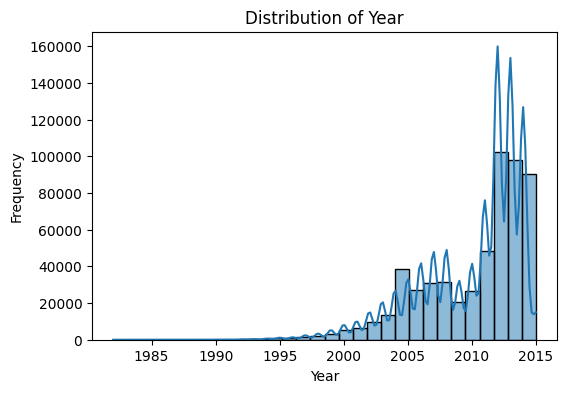

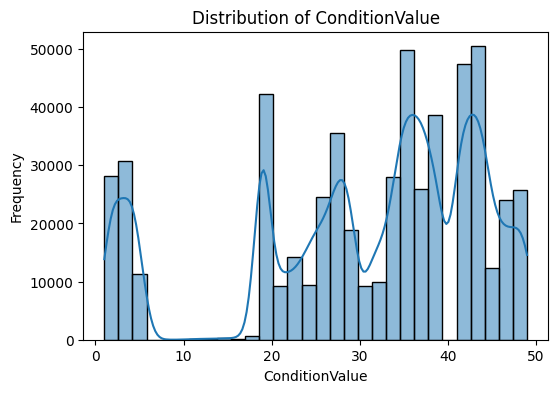

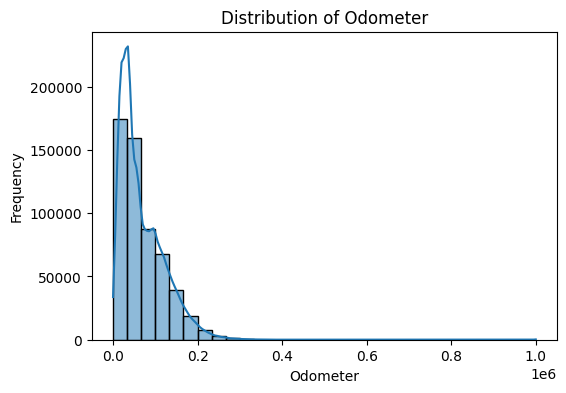

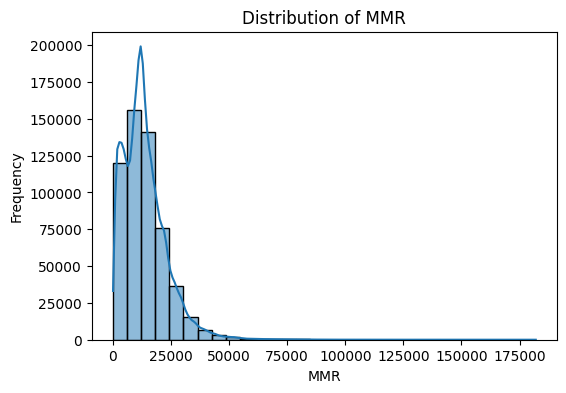

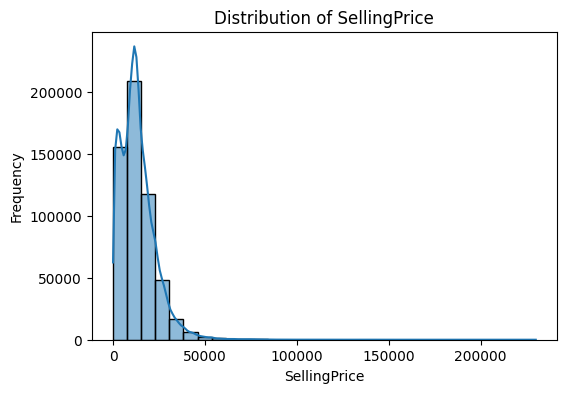

In [18]:
# discover Data Distribuation for numerical Columns
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

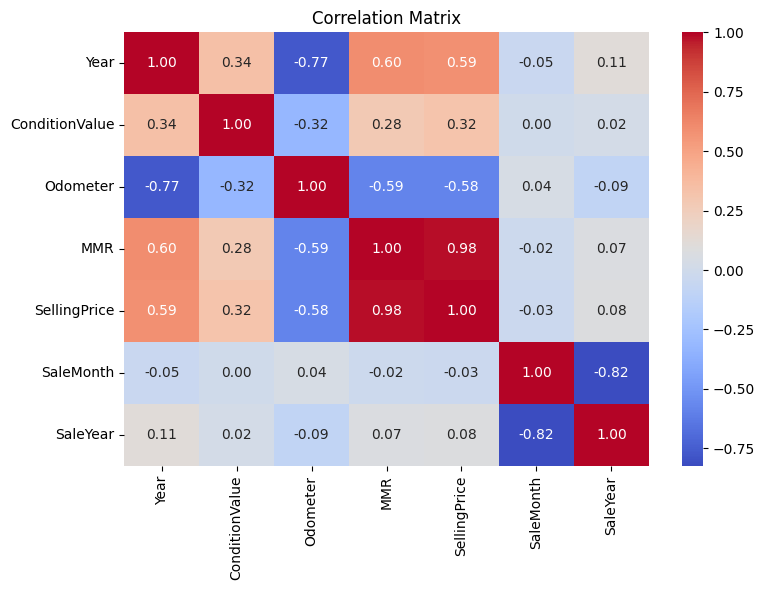

In [19]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Handle Misiing Values

In [20]:
# Baseline missing value count before any treatment
print("=== BEFORE IMPUTATION ===")
print(df.isnull().sum().sort_values(ascending=False))
print(f"\nTotal rows: {len(df)}")

=== BEFORE IMPUTATION ===
Transmission      65352
Body              13195
ConditionValue    11820
Trim              10651
Model             10399
Make              10301
Interior            749
Color               749
Odometer             94
SaleMonth            38
SaleYear             38
MMR                  38
SaleDate             38
SellingPrice         12
Year                  0
State                 0
Seller                0
dtype: int64

Total rows: 558837


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Year            558837 non-null  int64         
 1   Make            548536 non-null  category      
 2   Model           548438 non-null  category      
 3   Trim            548186 non-null  category      
 4   Body            545642 non-null  category      
 5   Transmission    493485 non-null  category      
 6   State           558837 non-null  category      
 7   ConditionValue  547017 non-null  float64       
 8   Odometer        558743 non-null  float64       
 9   Color           558088 non-null  category      
 10  Interior        558088 non-null  category      
 11  Seller          558837 non-null  object        
 12  MMR             558799 non-null  float64       
 13  SellingPrice    558825 non-null  float64       
 14  SaleDate        558799 non-null  dat

In [22]:
# Make / Model / Trim: structurally linked — missing any one means the car
# has no identity. Imputing BMW for a Kia destroys every price insight.
#
# SellingPrice: target variable — never impute it.
#
# SaleDate: transaction is incomplete without it; SaleMonth/SaleYear
# are derived from it so they fall away automatically.

rows_before = len(df)

df.dropna(subset=['Make', 'Model', 'Trim'], inplace=True)
df.dropna(subset=['SellingPrice'], inplace=True)
df.dropna(subset=['SaleDate'], inplace=True)

# Rebuild derived date columns after dropping (no orphaned NaNs)
df['SaleMonth'] = df['SaleDate'].dt.month
df['SaleYear']  = df['SaleDate'].dt.year

print(f"Rows dropped: {rows_before - len(df):,}")
print(f"Rows remaining: {len(df):,}")

Rows dropped: 10,787
Rows remaining: 548,050


In [23]:
df.isnull().sum().sort_values(ascending=False)

,0
Transmission,63550
ConditionValue,11635
Body,2544
Interior,729
Color,729
Odometer,88
Year,0
Trim,0
Model,0
State,0


In [24]:

# 1. Clean text safely
for col in ['Transmission', 'Body']:
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].replace(['nan', 'none', 'null',''], np.nan)


# 2. Group-based imputation
for col in ['Transmission', 'Body']:
    df[col] = df.groupby(['Make', 'Model'], observed=True)[col].transform(
        lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'unknown')
    )


# 3. Convert to category (final step)
for col in ['Transmission', 'Body']:
    df[col] = df[col].astype('category')


# 4. Validation
print("Transmission nulls remaining:", df['Transmission'].isnull().sum())
print("Body nulls remaining        :", df['Body'].isnull().sum())

Transmission nulls remaining: 0
Body nulls remaining        : 0


In [25]:
df.isnull().sum().sort_values(ascending=False)

,0
ConditionValue,11635
Interior,729
Color,729
Odometer,88
Year,0
Body,0
Trim,0
Make,0
Model,0
Transmission,0


In [26]:
# --- ISSUE 1: Numeric ghost categories ---
# Numeric-looking strings (e.g. '20379', '16633') leaked into the Color
# category vocabulary — likely from an index bleed during an earlier join.
# They have zero actual rows but pollute .value_counts() and encoders.
import re
for col in ['Color', 'Interior']:
    ghost_cats = [c for c in df[col].cat.categories if re.match(r'^\d+$', str(c))]
    if ghost_cats:
        print(f"{col}: removing {len(ghost_cats)} numeric ghost categories → {ghost_cats[:5]} ...")
        df[col] = df[col].cat.remove_categories(ghost_cats)
    else:
        print(f"{col}: no ghost categories found")

Color: removing 26 numeric ghost categories → ['11034', '1167', '12655', '14872', '15719'] ...
Interior: no ghost categories found


In [27]:
# --- ISSUE 2: Em-dash '—' is a dirty null ---
# 24,472 Color rows and 16,650 Interior rows contain '—' as a placeholder.
# This was NOT caught by isnull() because it is a real string value.
# True missing picture:
#   Color:    749 NaN  +  24,472 em-dash  =  25,221 total (4.5%)
#   Interior: 749 NaN  +  16,650 em-dash  =  17,399 total (3.1%)
#
# Strategy: treat '—' as Unknown rather than imputing a color,
# because color is a cosmetic attribute — not structurally determined
# by Make/Model. Imputing would inject artificial bias into color analysis.

# --- Fix hidden missing values (NaN + em-dash + other placeholders) ---

for col in ['Color', 'Interior']:

    # 1. Normalize obvious dirty strings to NaN
    df[col] = df[col].replace(['—', 'nan', 'none', 'null', ''], np.nan)

    # 2. Convert to category safely AFTER cleaning
    df[col] = df[col].astype('category')

    # 3. Ensure 'Unknown' exists as a valid category
    if 'Unknown' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories('Unknown')

    # 4. Fill all missing values uniformly
    df[col] = df[col].fillna('Unknown')
print("Color nulls remaining   :", df['Color'].isnull().sum())
print("Interior nulls remaining:", df['Interior'].isnull().sum())
print("\nColor value counts (top 10):")
print(df['Color'].value_counts().head(10))

Color nulls remaining   : 0
Interior nulls remaining: 0

Color value counts (top 10):
Color
black      109031
white      104214
silver      81817
gray        81786
blue        50023
red         42717
Unknown     25201
gold        10984
green       10936
beige        8981
Name: count, dtype: int64


/tmp/ipykernel_13226/3878458482.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[col] = df[col].replace(['—', 'nan', 'none', 'null', ''], np.nan)


In [28]:
# Condition correlates with mileage and age — not just Make/Model identity.
# A 2015 BMW with 2K miles and a 2012 truck with 80K miles should not
# receive the same imputed condition score.
#
# Strategy:
#   1. Bin Odometer into 5 quantile bands (low → high mileage)
#   2. Impute using median within Make + OdometerBand group
#   3. Global median fallback for any group that is entirely null

df['_OdometerBand'] = pd.cut(
    df['Odometer'],
    bins=[0, 20000, 50000, 100000, 150000, df['Odometer'].max()],
    labels=False
)
df['ConditionValue'] = df.groupby(['Make', '_OdometerBand'], observed=True)['ConditionValue'].transform(
    lambda x: x.fillna(x.median())
)

# Global fallback
df['ConditionValue'] = df['ConditionValue'].fillna(df['ConditionValue'].median())

# Drop helper column
df.drop(columns=['_OdometerBand'], inplace=True)

print("ConditionValue nulls remaining:", df['ConditionValue'].isnull().sum())

ConditionValue nulls remaining: 0


In [29]:
# Odometer is right-skewed — median is robust to high-mileage outliers.
# Grouping by Make+Model ensures a 2015 Kia median is not contaminated
# by 2012 truck mileage distributions.

df['Odometer'] = df.groupby(['Make', 'Model'], observed=True)['Odometer'].transform(
    lambda x: x.fillna(x.median())
)

# Global fallback
df['Odometer'] = df['Odometer'].fillna(df['Odometer'].median())

print("Odometer nulls remaining:", df['Odometer'].isnull().sum())

Odometer nulls remaining: 0


In [30]:
# MMR (Manheim Market Report) is the market benchmark used to validate
# SellingPrice. Imputing it would be circular — we use MMR to judge
# whether a price is above/below market, so a fabricated MMR corrupts
# that entire analysis. Only 38 rows affected — negligible loss.

rows_before = len(df)
df = df.dropna(subset=['MMR'])
print(f"Rows dropped: {rows_before - len(df)}")
print(f"MMR nulls remaining: {df['MMR'].isnull().sum()}")

Rows dropped: 0
MMR nulls remaining: 0


In [31]:
print("=" * 50)
print("FINAL PREPROCESSING AUDIT")
print("=" * 50)

print(f"\nFinal shape: {df.shape}")

nulls = df.isnull().sum()
nulls_remaining = nulls[nulls > 0]
if nulls_remaining.empty:
    print("\n✓ Zero null values remaining across all columns")
else:
    print("\n⚠ Nulls still remaining:")
    print(nulls_remaining)

print("\n--- Dirty value checks ---")
print(f"Em-dash in Color   : {(df['Color'] == '—').sum()}")
print(f"Em-dash in Interior: {(df['Interior'] == '—').sum()}")

for col in ['Color', 'Interior']:
    ghost = [c for c in df[col].cat.categories if re.match(r'^\d+$', str(c))]
    print(f"Ghost numeric cats in {col}: {len(ghost)}")

print("\n--- Column distributions ---")
print("Transmission:\n", df['Transmission'].value_counts())
print("\nBody:\n", df['Body'].value_counts())
print("\nColor (top 10):\n", df['Color'].value_counts().head(10))

print("\n--- Numerical summary ---")
print(df[['ConditionValue', 'Odometer', 'MMR', 'SellingPrice']].describe().round(2))

FINAL PREPROCESSING AUDIT

Final shape: (548050, 17)

✓ Zero null values remaining across all columns

--- Dirty value checks ---
Em-dash in Color   : 0
Em-dash in Interior: 0
Ghost numeric cats in Color: 0
Ghost numeric cats in Interior: 0

--- Column distributions ---
Transmission:
 Transmission
automatic    530932
manual        17042
unknown          76
Name: count, dtype: int64

Body:
 Body
sedan                      241234
suv                        143844
hatchback                   26237
minivan                     25529
coupe                       17752
crew cab                    16394
wagon                       16128
convertible                 10476
supercrew                    9033
g sedan                      7417
supercab                     5311
regular cab                  4850
van                          4528
extended cab                 4507
quad cab                     4095
unknown                      2544
e-series van                 1823
double cab              

In [32]:
for col in categorical_cols:
    print(f"\n{col} value counts:\n", df[col].value_counts())


Make value counts:
 Make
Ford          93553
Chevrolet     60179
Nissan        53946
Toyota        39871
Dodge         30708
              ...  
ford tk           1
mercedes-b        1
hyundai tk        1
dot               0
mazda tk          0
Name: count, Length: 96, dtype: int64

Model value counts:
 Model
Altima     19349
F-150      14479
Fusion     12945
Camry      12545
Escape     11861
           ...  
pursuit        0
versa          0
wave           0
320i           0
300e           0
Name: count, Length: 973, dtype: int64

Trim value counts:
 Trim
Base                        55815
SE                          43646
LX                          20756
Limited                     18367
LT                          16915
                            ...  
xl                              1
zx3                             1
xlt 4x4 xlt sc                  1
2.0 TFSI Premium quattro        0
SE PZEV w/Connectivity          0
Name: count, Length: 1963, dtype: int64

Body value counts:
 B

In [33]:
df.isnull().sum()

,0
Year,0
Make,0
Model,0
Trim,0
Body,0
Transmission,0
State,0
ConditionValue,0
Odometer,0
Color,0


## Handle Duplicates

In [34]:
df.duplicated().sum()

np.int64(0)

## Outliers

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 548050 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Year            548050 non-null  int64         
 1   Make            548050 non-null  category      
 2   Model           548050 non-null  category      
 3   Trim            548050 non-null  category      
 4   Body            548050 non-null  category      
 5   Transmission    548050 non-null  category      
 6   State           548050 non-null  category      
 7   ConditionValue  548050 non-null  float64       
 8   Odometer        548050 non-null  float64       
 9   Color           548050 non-null  category      
 10  Interior        548050 non-null  category      
 11  Seller          548050 non-null  object        
 12  MMR             548050 non-null  float64       
 13  SellingPrice    548050 non-null  float64       
 14  SaleDate        548050 non-null  datetime

In [36]:
df['SellingPrice'].describe()

,SellingPrice
count,548050.000000
mean,13693.539009
std,9702.409543
min,1.000000
25%,7000.000000
50%,12200.000000
75%,18300.000000
max,230000.000000


In [37]:
df['Odometer'].describe()

,Odometer
count,548050.000000
mean,67518.362479
std,52887.827014
min,1.000000
25%,28136.000000
50%,51389.000000
75%,97890.750000
max,999999.000000


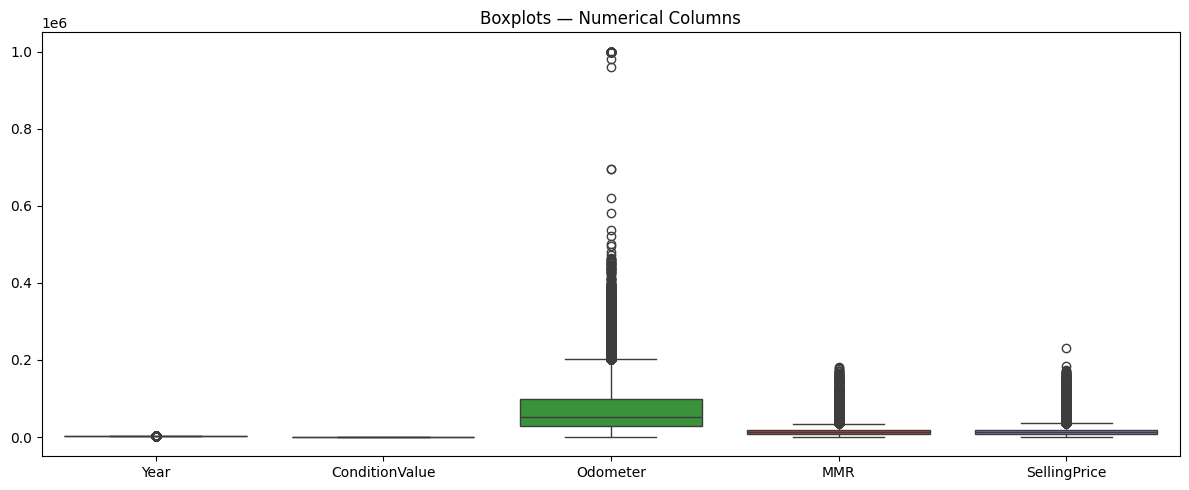

In [38]:
# Boxplots to spot outliers in numerical columns
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[numerical_cols])
plt.title('Boxplots — Numerical Columns')
plt.tight_layout()
plt.show()

In [39]:
df['SaleYear'] = df['SaleDate'].dt.year

Odometer = 999999: 68
Odometer > 300000: 683


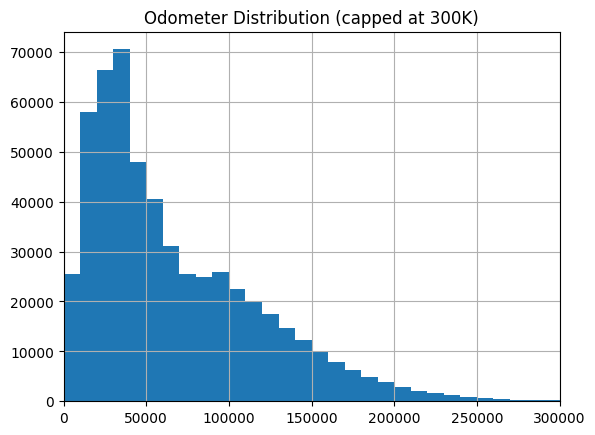

In [40]:
# Check how many rows are affected
print("Odometer = 999999:", (df['Odometer'] == 999999).sum())
print("Odometer > 300000:", (df['Odometer'] > 300000).sum())

# Visualize the tail
df['Odometer'].hist(bins=100)
plt.xlim(0, 300000)
plt.title('Odometer Distribution (capped at 300K)')
plt.show()

## solve some unknown values

In [41]:
import re

# ── STATE ──────────────────────────────────────────────────────────────────────
# VIN-like strings are zero-count ghost categories — no real rows affected
# We remove them from the category vocabulary only, no fillna needed

dirty_states = [
    s for s in df['State'].cat.categories
    if re.match(r'^[0-9a-z]{17}$', str(s))
]
print(f"Ghost state categories removed: {len(dirty_states)}")

df['State'] = df['State'].cat.remove_categories(dirty_states)

print(f"State nulls after removal : {df['State'].isnull().sum()}")  # expect 0
print(f"Clean state categories    : {df['State'].nunique()}")


# ── MAKE ───────────────────────────────────────────────────────────────────────
# These dirty values have real rows (ford tk=1, hyundai tk=1, mercedes-b=1)
# We fix them in place — do NOT drop, do NOT impute with mode

df['Make'] = (
    df['Make']
    .astype(str)
    .str.strip()
    .replace('nan', np.nan)               # restore nulls lost by astype(str)
    .str.replace(r'\s*tk$', '', regex=True)   # 'ford tk'    → 'ford'
    .str.replace(r'-+$',    '', regex=True)   # 'mercedes-b' → 'mercedes'
    .str.strip()                              # clean any trailing spaces
    .str.title()                              # 'ford' → 'Ford'
)

# .title() mangles acronym brands — fix explicitly
brand_fixes = {
    'Bmw'        : 'BMW',
    'Gmc'        : 'GMC',
    'Mercedes-B' : 'Mercedes-Benz',
}
df['Make'] = df['Make'].replace(brand_fixes)
df['Make'] = df['Make'].astype('category')


# ── VALIDATION ─────────────────────────────────────────────────────────────────
print("\nTop 10 States:")
print(df['State'].value_counts().head(10))

print("\nMake tail (check for leftover dirty values):")
print(df['Make'].value_counts().tail(10))

print(f"\nMake  nulls: {df['Make'].isnull().sum()}")
print(f"State nulls: {df['State'].isnull().sum()}")

Ghost state categories removed: 26
State nulls after removal : 0
Clean state categories    : 38

Top 10 States:
State
fl    81424
ca    71570
pa    53146
tx    45156
ga    34039
nj    27322
il    23182
nc    21312
oh    21203
tn    20686
Name: count, dtype: int64

Make tail (check for leftover dirty values):
Make
Rolls-Royce    17
Gmc Truck      11
Mercedes       10
Fisker          9
Lamborghini     4
Daewoo          3
Ford Truck      3
Chev Truck      1
Airstream       1
Lotus           1
Name: count, dtype: int64

Make  nulls: 0
State nulls: 0


In [42]:
df['Make'].value_counts()

,count
Make,
Ford,93991
Chevrolet,60480
Nissan,53986
Toyota,39960
Dodge,30942
Honda,27345
Hyundai,21831
BMW,20704
Kia,18079


In [43]:
df['State'].value_counts()

,count
State,
fl,81424
ca,71570
pa,53146
tx,45156
ga,34039
nj,27322
il,23182
nc,21312
oh,21203


In [44]:
for col in categorical_cols:
    print(f"\n{col} value counts:\n", df[col].value_counts())


Make value counts:
 Make
Ford             93991
Chevrolet        60480
Nissan           53986
Toyota           39960
Dodge            30942
Honda            27345
Hyundai          21831
BMW              20704
Kia              18079
Chrysler         17483
Mercedes-Benz    17142
Jeep             15482
Infiniti         15305
Volkswagen       12576
Lexus            11980
GMC              10638
Mazda             8444
Cadillac          7625
Acura             5903
Audi              5865
Lincoln           5786
Buick             5121
Subaru            5103
Ram               4574
Pontiac           4520
Mitsubishi        4253
Volvo             3788
Mini              3224
Saturn            2841
Mercury           2022
Land Rover        1864
Scion             1687
Jaguar            1420
Porsche           1401
Suzuki            1077
Fiat               865
Hummer             805
Saab               484
Smart              396
Oldsmobile         383
Isuzu              204
Maserati           134
Bentley 

In [45]:
# ── PROBLEM 1: Duplicate brand names ──────────────────────────────────
brand_merge = {
    'Landrover'  : 'Land Rover',
    'Vw'         : 'Volkswagen',
    'Gmc Truck'  : 'GMC',
    'Mercedes'   : 'Mercedes-Benz',
    'Ford Truck' : 'Ford',
    'Chev Truck' : 'Chevrolet',
}
df['Make'] = df['Make'].cat.add_categories(
    [v for v in brand_merge.values() if v not in df['Make'].cat.categories]
)
df['Make'] = df['Make'].replace(brand_merge).cat.remove_unused_categories()

# ── PROBLEM 2: Ghost categories in Model & Trim ────────────────────────
for col in ['Model', 'Trim']:
    df[col] = df[col].astype('category')
    ghost = [c for c in df[col].cat.categories if df[col].value_counts()[c] == 0]
    df[col] = df[col].cat.remove_categories(ghost)
    print(f"{col}: removed {len(ghost)} ghost categories")

# ── PROBLEM 3: Consolidate Body types ─────────────────────────────────
body_map = {
    # Crew cab variants
    'supercrew'    : 'crew cab',
    'quad cab'     : 'crew cab',
    'double cab'   : 'crew cab',
    'crewmax cab'  : 'crew cab',
    'mega cab'     : 'crew cab',
    # Extended cab variants
    'supercab'     : 'extended cab',
    'club cab'     : 'extended cab',
    'king cab'     : 'extended cab',
    'cab plus'     : 'extended cab',
    'cab plus 4'   : 'extended cab',
    'access cab'   : 'extended cab',
    'xtracab'      : 'extended cab',
    'regular-cab'  : 'regular cab',
    # Coupe variants
    'g coupe'          : 'coupe',
    'genesis coupe'    : 'coupe',
    'koup'             : 'coupe',
    'cts coupe'        : 'coupe',
    'cts-v coupe'      : 'coupe',
    'q60 coupe'        : 'coupe',
    'g37 coupe'        : 'coupe',
    'elantra coupe'    : 'coupe',
    # Convertible variants
    'g convertible'            : 'convertible',
    'beetle convertible'       : 'convertible',
    'granturismo convertible'  : 'convertible',
    'q60 convertible'          : 'convertible',
    'g37 convertible'          : 'convertible',
    # Wagon variants
    'tsx sport wagon' : 'wagon',
    'cts wagon'       : 'wagon',
    'cts-v wagon'     : 'wagon',
    # Van variants
    'e-series van'        : 'van',
    'transit van'         : 'van',
    'ram van'             : 'van',
    'promaster cargo van' : 'van',
    # Sedan variants
    'g sedan'         : 'sedan',
}
df['Body'] = df['Body'].replace(body_map).astype('category')

# ── VALIDATION ─────────────────────────────────────────────────────────
print("\nMake value counts:")
print(df['Make'].value_counts())
print("\nBody value counts:")
print(df['Body'].value_counts())

/tmp/ipykernel_13226/1251522803.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Make'] = df['Make'].replace(brand_merge).cat.remove_unused_categories()


Model: removed 23 ghost categories
Trim: removed 2 ghost categories

Make value counts:
Make
Ford             93994
Chevrolet        60481
Nissan           53986
Toyota           39960
Dodge            30942
Honda            27345
Hyundai          21831
BMW              20704
Kia              18079
Chrysler         17483
Mercedes-Benz    17152
Jeep             15482
Infiniti         15305
Volkswagen       12600
Lexus            11980
GMC              10649
Mazda             8444
Cadillac          7625
Acura             5903
Audi              5865
Lincoln           5786
Buick             5121
Subaru            5103
Ram               4574
Pontiac           4520
Mitsubishi        4253
Volvo             3788
Mini              3224
Saturn            2841
Mercury           2022
Land Rover        1890
Scion             1687
Jaguar            1420
Porsche           1401
Suzuki            1077
Fiat               865
Hummer             805
Saab               484
Smart              396
Oldsmobile

/tmp/ipykernel_13226/1251522803.py:66: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Body'] = df['Body'].replace(body_map).astype('category')


In [46]:
for col in categorical_cols:
    print(f"\n{col} value counts:\n", df[col].value_counts())


Make value counts:
 Make
Ford             93994
Chevrolet        60481
Nissan           53986
Toyota           39960
Dodge            30942
Honda            27345
Hyundai          21831
BMW              20704
Kia              18079
Chrysler         17483
Mercedes-Benz    17152
Jeep             15482
Infiniti         15305
Volkswagen       12600
Lexus            11980
GMC              10649
Mazda             8444
Cadillac          7625
Acura             5903
Audi              5865
Lincoln           5786
Buick             5121
Subaru            5103
Ram               4574
Pontiac           4520
Mitsubishi        4253
Volvo             3788
Mini              3224
Saturn            2841
Mercury           2022
Land Rover        1890
Scion             1687
Jaguar            1420
Porsche           1401
Suzuki            1077
Fiat               865
Hummer             805
Saab               484
Smart              396
Oldsmobile         383
Isuzu              204
Maserati           134
Bentley 

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 548050 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Year            548050 non-null  int64         
 1   Make            548050 non-null  category      
 2   Model           548050 non-null  category      
 3   Trim            548050 non-null  category      
 4   Body            548050 non-null  category      
 5   Transmission    548050 non-null  category      
 6   State           548050 non-null  category      
 7   ConditionValue  548050 non-null  float64       
 8   Odometer        548050 non-null  float64       
 9   Color           548050 non-null  category      
 10  Interior        548050 non-null  category      
 11  Seller          548050 non-null  object        
 12  MMR             548050 non-null  float64       
 13  SellingPrice    548050 non-null  float64       
 14  SaleDate        548050 non-null  datetime

In [48]:
df.describe()

,Year,ConditionValue,Odometer,MMR,SellingPrice,SaleDate,SaleMonth,SaleYear
count,548050.000000,548050.000000,548050.000000,548050.000000,548050.000000,548050,548050.000000,548050.000000
mean,2010.117610,30.717198,67518.362479,13853.182739,13693.539009,2015-03-05 20:35:12.805766656,3.811922,2014.902516
min,1989.000000,1.000000,1.000000,25.000000,1.000000,2014-01-01 01:15:00,1.000000,2014.000000
25%,2008.000000,24.000000,28136.000000,7275.000000,7000.000000,2015-01-20 18:00:00,1.000000,2015.000000
50%,2012.000000,34.000000,51389.000000,12350.000000,12200.000000,2015-02-12 17:20:00,2.000000,2015.000000
75%,2013.000000,41.000000,97890.750000,18400.000000,18300.000000,2015-05-21 18:45:00,6.000000,2015.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000,2015-07-20 19:30:00,12.000000,2015.000000
std,3.905911,13.272000,52887.827014,9630.861478,9702.409543,NaN,3.244148,0.296616


In [49]:
df.to_csv('/content/drive/My Drive/ai_projects/car_price_hackthon_sha/data/cleaned_data.csv', index=False)